In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
import os
from tqdm import tqdm

In [29]:
import sys
import os

# Trỏ đường dẫn ngược ra thư mục gốc của dự án
sys.path.append(os.path.abspath('..'))

from src.preprocessing import fabryzzio_segmentation
print("✅ Đã load thành công hàm tách nền từ thư mục src!")

✅ Đã load thành công hàm tách nền từ thư mục src!


In [26]:
data_dir = '../data/raw/PlantVillage' 

output_dir = '../data/segmented/dataset_segmented' 

os.makedirs(output_dir, exist_ok=True)

In [ ]:
MORPH_OPEN_K   = 3  # Kích thước chổi quét nhiễu ngoài nền
MORPH_CLOSE_K  = 5  # Kích thước chổi lấp lỗ hổng trong lá
RATIO_VALID_LO = 0.10 # Lá phải chiếm > 10% ảnh
RATIO_VALID_HI = 0.90 # Lá phải chiếm < 90% ảnh
RATIO_TARGET   = 0.38 # Kích thước lý tưởng của lá PlantVillage là 38% ảnh

# ========================================================================
# 2. HỆ THỐNG TÁCH NỀN BÌNH DUYỆT KÉP (FABRYZZIO)
# ========================================================================
def compute_chroma(img_lab):
    a = img_lab[:, :, 1].astype(np.float32) - 128.0
    b = img_lab[:, :, 2].astype(np.float32) - 128.0
    return np.clip(np.sqrt(a**2 + b**2), 0, 255).astype(np.uint8)

def area_ratio(mask):
    return float(np.count_nonzero(mask)) / (mask.shape[0] * mask.shape[1])

def refine_mask(raw_mask):
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_OPEN_K, MORPH_OPEN_K))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_CLOSE_K, MORPH_CLOSE_K))
    
    opened = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, k_open, iterations=1)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, k_close, iterations=2)
    
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(closed)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    
    return filled_mask

def fabryzzio_segmentation(img_path, img_size=(256, 256)):
    bgr = cv2.imread(img_path)
    if bgr is None: return None, None, None, None
    rgb = cv2.resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), img_size)
    
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.medianBlur(gray, 3) 
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2Lab)
    
    _, mask_L = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    chroma = compute_chroma(lab)
    _, mask_C = cv2.threshold(chroma, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    final_L = refine_mask(mask_L)
    final_C = refine_mask(mask_C)
    
    r_L = area_ratio(final_L)
    r_C = area_ratio(final_C)
    
    L_ok = RATIO_VALID_LO <= r_L <= RATIO_VALID_HI
    C_ok = RATIO_VALID_LO <= r_C <= RATIO_VALID_HI
    
    if L_ok and C_ok:
        if abs(r_L - RATIO_TARGET) <= abs(r_C - RATIO_TARGET):
            best_mask, channel = final_L, "Luminance (Ánh sáng)"
        else:
            best_mask, channel = final_C, "Chroma (Sắc độ)"
    elif L_ok:
        best_mask, channel = final_L, "Luminance (Fallback)"
    elif C_ok:
        best_mask, channel = final_C, "Chroma (Fallback)"
    else:
        best_mask = final_L if r_L >= r_C else final_C
        channel = "Failed"
        
    result_rgb = cv2.bitwise_and(rgb, rgb, mask=best_mask)
    return rgb, best_mask, result_rgb, channel

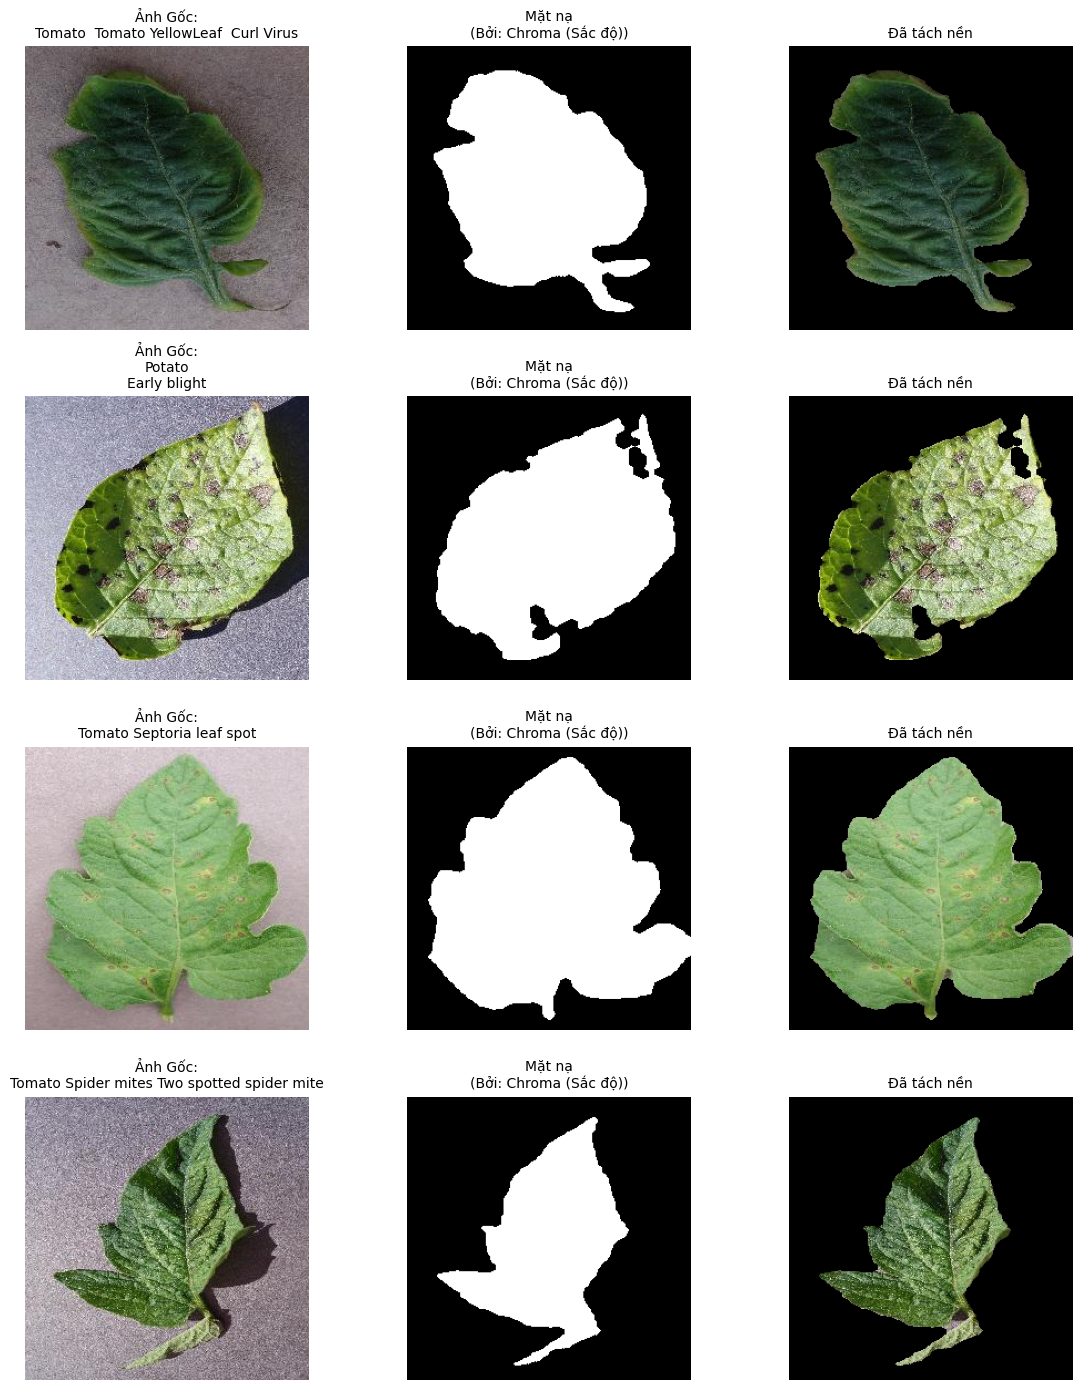

In [37]:

all_images = glob.glob(os.path.join(data_dir, '*/*.*'))

# Nếu báo lỗi không tìm thấy ảnh, hãy kiểm tra lại biến data_dir ở trên
if len(all_images) == 0:
    print("⚠️ Không tìm thấy ảnh nào! Vui lòng kiểm tra lại đường dẫn data_dir.")
else:
    sample_imgs = random.sample(all_images, min(4, len(all_images)))
    
    fig, axs = plt.subplots(4, 3, figsize=(12, 14))
    
    for i, img_path in enumerate(sample_imgs):
        # GỌI HÀM TỪ FILE PYTHON BÊN NGOÀI
        rgb, mask, result, channel = fabryzzio_segmentation(img_path)
        
        if rgb is None: continue
        
        # Lấy tên bệnh để in ra cho đẹp
        class_name = img_path.split(os.sep)[-2].replace('___', '\n').replace('_', ' ')
        
        # Vẽ hình
        axs[i, 0].imshow(rgb)
        axs[i, 0].set_title(f'Ảnh Gốc:\n{class_name}', fontsize=10)
        axs[i, 0].axis('off')
        
        axs[i, 1].imshow(mask, cmap='gray')
        axs[i, 1].set_title(f'Mặt nạ\n(Bởi: {channel})', fontsize=10)
        axs[i, 1].axis('off')
        
        axs[i, 2].imshow(result)
        axs[i, 2].set_title('Đã tách nền', fontsize=10)
        axs[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
print(f"\n--- BẮT ĐẦU QUÁ TRÌNH TÁCH NỀN VÀ LƯU FILE ({len(all_images)} ẢNH) ---")
os.makedirs(output_dir, exist_ok=True)

# Lặp qua toàn bộ ảnh với thanh tiến trình
for img_path in tqdm(all_images, desc="Tiến độ lưu file"):
    # Lấy tên Class và tên Tệp ảnh
    path_parts = img_path.split(os.sep)
    class_name = path_parts[-2]
    file_name = path_parts[-1]
    
    # Tạo thư mục cho Class đó trong dataset_segmented
    class_output_dir = os.path.join(output_dir, class_name)
    os.makedirs(class_output_dir, exist_ok=True)
    
    save_path = os.path.join(class_output_dir, file_name)
    
    # Bỏ qua nếu file đã được xử lý từ trước (đề phòng Colab bị sập giữa chừng)
    if os.path.exists(save_path): continue
    
    # Thực hiện tách nền
    _, _, result_rgb, _ = fabryzzio_segmentation(img_path)
    
    if result_rgb is not None:
        # Chuyển hệ màu từ RGB (Matplotlib) về lại BGR (OpenCV) để lưu file đúng màu
        result_bgr = cv2.cvtColor(result_rgb, cv2.COLOR_RGB2BGR)
        cv2.imwrite(save_path, result_bgr)

print(f"\n🎉 HOÀN TẤT! Toàn bộ ảnh đã được lưu sạch sẽ tại thư mục: '{output_dir}'")